In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [5]:
df1 =  pd.read_csv("European_Bank.csv")
df = df1.copy()
df

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


<Axes: xlabel='Age', ylabel='Balance'>

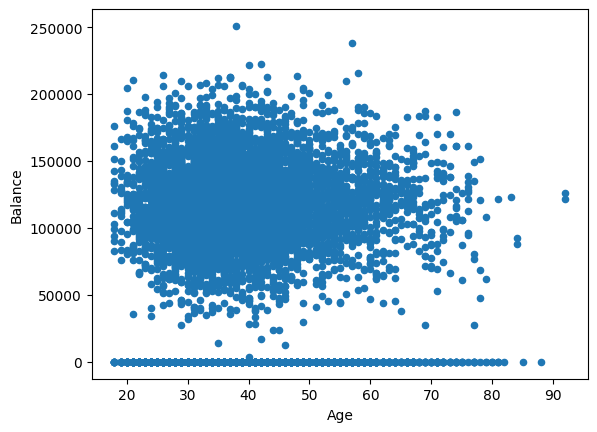

In [6]:
df.plot(kind = "scatter", x = "Age", y = "Balance")

In [3]:
# Remove columns
df.drop(["CustomerId","Surname","Year"], axis=1, inplace=True)

# Encode Gender
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# One Hot Encode Geography
df = pd.get_dummies(df,
                    columns=["Geography"],
                    drop_first=True)

# Convert bool to int
df["Geography_Germany"] = df["Geography_Germany"].astype(int)
df["Geography_Spain"] = df["Geography_Spain"].astype(int)

print(df.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1                  0                0  
1               1        112542.58       0                  0                1  
2               0        113931.57       1                  0                0  
3               0         93826.63       0                  0                0  
4               1         79084.10       0                  0                1  


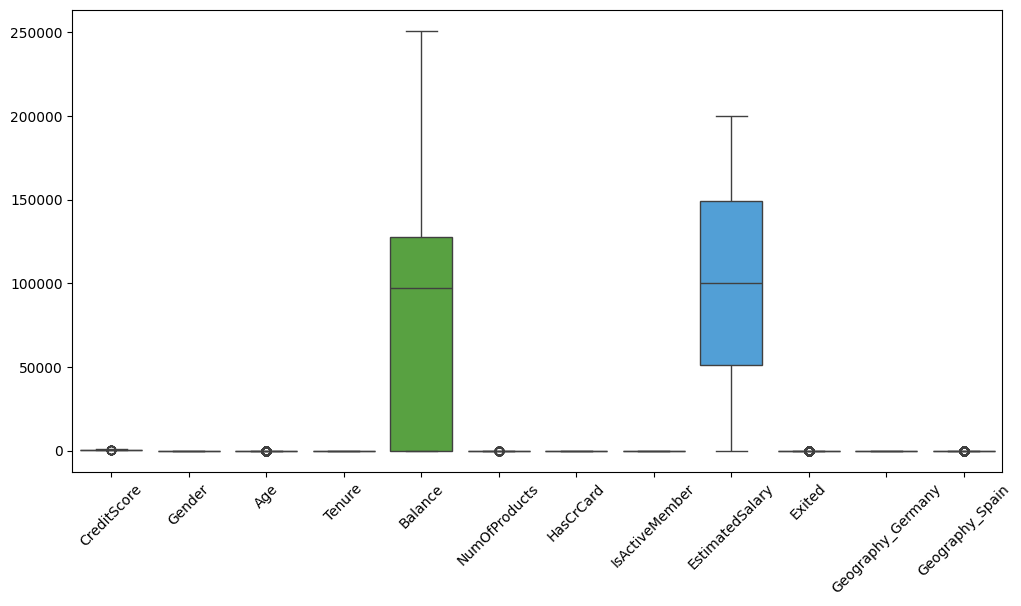

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

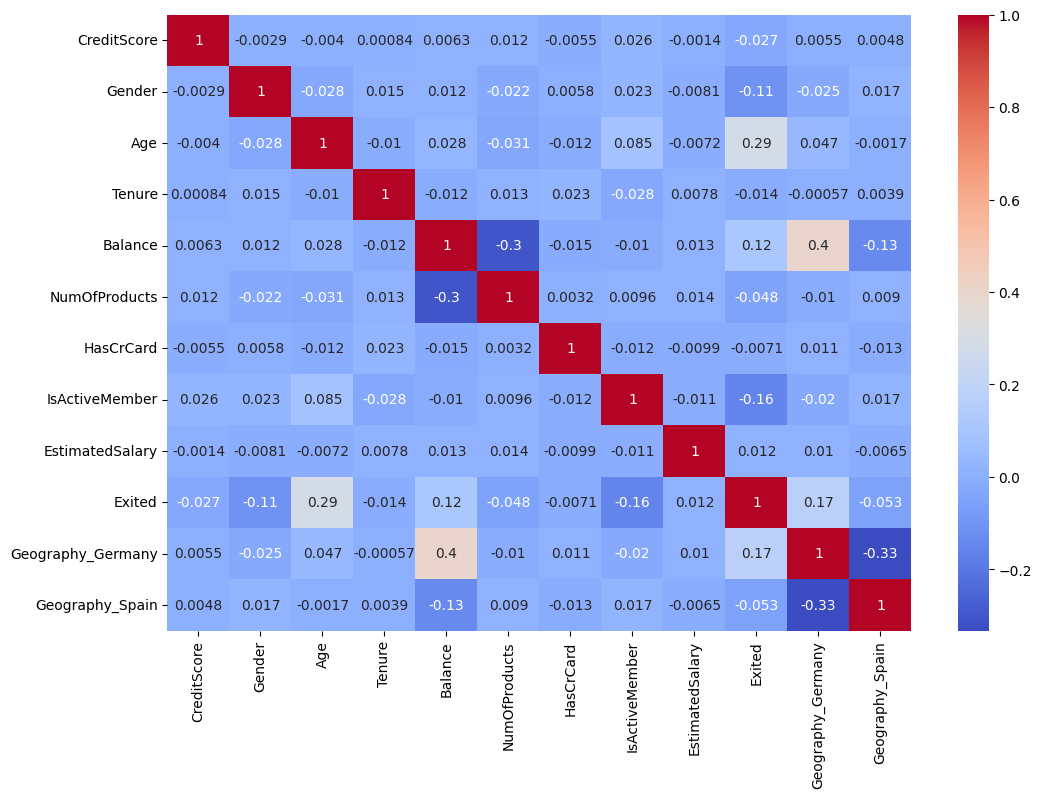

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

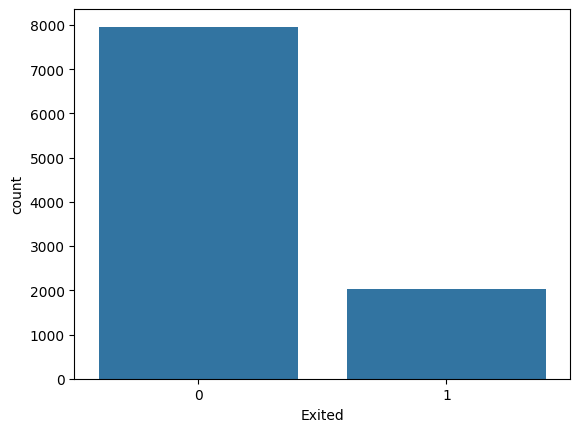

Exited
0    7963
1    2037
Name: count, dtype: int64


In [6]:
sns.countplot(x='Exited', data=df)
plt.show()

print(df['Exited'].value_counts())

In [7]:
germany_churn = df.groupby('Geography_Germany')['Exited'].mean()
print(germany_churn)

spain_churn = df.groupby('Geography_Spain')['Exited'].mean()
print(spain_churn)

Geography_Germany
0    0.163263
1    0.324432
Name: Exited, dtype: float64
Geography_Spain
0    0.215871
1    0.166734
Name: Exited, dtype: float64


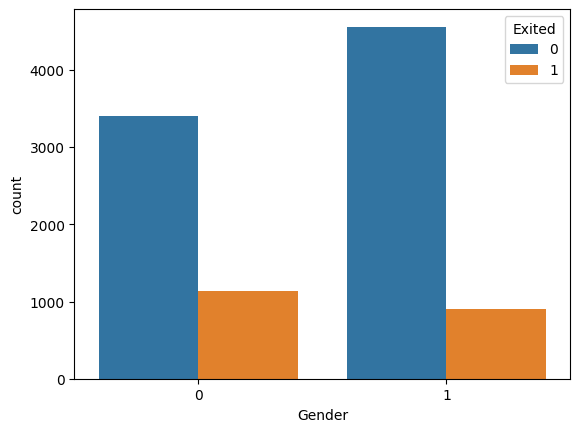

In [8]:
sns.countplot(x='Gender',
              hue='Exited',
              data=df)
plt.show()

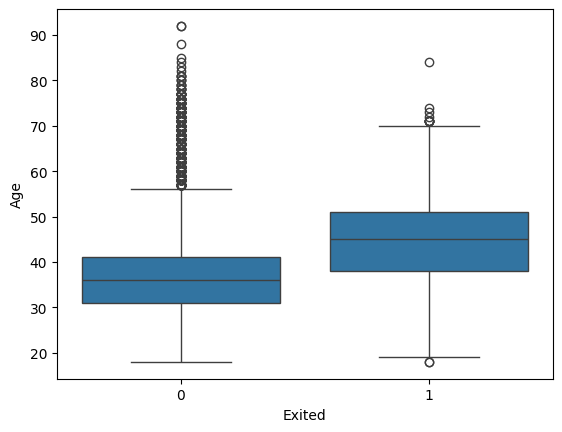

In [9]:
sns.boxplot(x='Exited',
            y='Age',
            data=df)
plt.show()

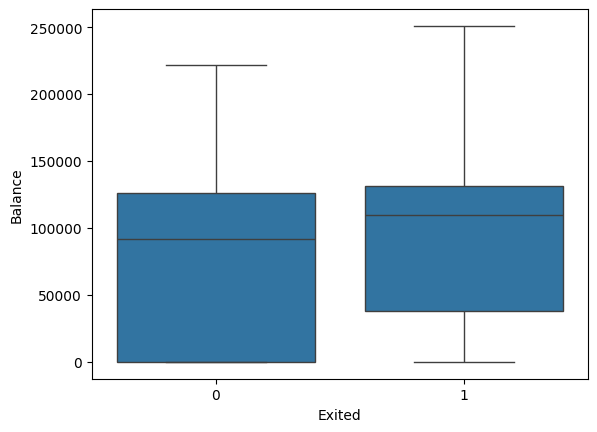

In [10]:
sns.boxplot(x='Exited',
            y='Balance',
            data=df)
plt.show()